### Desplazamiento ideológico (H2/H3) — bielección (bloque largo t-2 -> t)

Misma estructura que `ventana_t-1/03_desplazamiento_ideologico.ipynb`, sobre
`data/tfi_data/panel_ventanas_bieleccion.csv` en vez de `panel_ventanas.csv`
-- predictores de trayectoria trimestral `_trim` (bloque largo) en vez de
`_vc` (ventana corta), predictor H3 derivado del extremo `t-2` en vez de
`t-1`. Variable dependiente: `magnitud_desplazamiento_ideologico` (D18),
ya calculada en el panel bielección con la misma fórmula.

**Disciplina H1/H4 vs. H2/H3 (D18):** `delta_dispersion_economico_mu`,
`delta_dispersion_progresismo_mu`, `magnitud_desplazamiento_ideologico` y
`cuadrante_desplazamiento` son variables dependientes de H2 -- nunca deben
entrar como predictor de H1/H4.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

general_path = "/workspaces/analisis-politica-economia/"
data_path = f"{general_path}data/tfi_data/"
sys.path.insert(0, f"{general_path}/src")
from ml_models.cargar_panel import cargar_panel, columnas_candidatas

NIVELES = ["municipal", "provincial", "nacional"]
paneles = {nivel: cargar_panel(nivel, f"{data_path}panel_ventanas_bieleccion.csv") for nivel in NIVELES}
distancias = pd.read_csv(f"{data_path}distancias_ideologicas.csv")

for nivel, df in paneles.items():
    print(f"{nivel}: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"distancias_ideologicas: {distancias.shape[0]} filas x {distancias.shape[1]} columnas")

municipal: 11 filas x 90 columnas
provincial: 11 filas x 90 columnas
nacional: 11 filas x 90 columnas
distancias_ideologicas: 269 filas x 11 columnas


### Paso 1 — Predictores: batería `_trim` reducida por colinealidad

La reducción depende solo de la colinealidad entre predictores, no del
target, así que da el mismo resultado sin importar qué se vaya a predecir
con `X`.

In [2]:
nivel_referencia = "municipal"
df_ref = paneles[nivel_referencia]
cols_vc = columnas_candidatas(df_ref, excluir_adicional=["magnitud_desplazamiento_ideologico"])
corr = df_ref[cols_vc].corr(method="pearson")

UMBRAL_REDUNDANCIA = 0.90
PRIORIDAD_TEORICA = ["ipc", "desocupacion", "icg", "icc", "salario_real", "tc_oficial", "reservas", "resultado_fiscal", "emae"]
ORDEN_SUFIJO = ["_nivel_trim", "_final_trim", "_pendiente_trim", "_volatilidad_trim"]


def encontrar_redundantes(corr: pd.DataFrame, umbral: float) -> list[set[str]]:
    cols = list(corr.columns)
    adyacencia = {c: set() for c in cols}
    for i, a in enumerate(cols):
        for b in cols[i + 1:]:
            if abs(corr.loc[a, b]) >= umbral:
                adyacencia[a].add(b)
                adyacencia[b].add(a)
    visit, clusters = set(), []
    for c in cols:
        if c in visit:
            continue
        stack, cluster = [c], set()
        while stack:
            actual = stack.pop()
            if actual in cluster:
                continue
            cluster.add(actual)
            stack.extend(adyacencia[actual] - cluster)
        visit |= cluster
        clusters.append(cluster)
    return clusters


def elegir_representante(cluster: set[str]) -> str:
    def clave(col):
        pref_sufijo = next((i for i, s in enumerate(ORDEN_SUFIJO) if col.endswith(s)), 99)
        variable = next((v for v in PRIORIDAD_TEORICA if col.startswith(v + "_")), None)
        pref_teorica = PRIORIDAD_TEORICA.index(variable) if variable else 99
        return (pref_sufijo, pref_teorica, col)
    return min(cluster, key=clave)


clusters = encontrar_redundantes(corr, UMBRAL_REDUNDANCIA)
cols_finales = [elegir_representante(cl) if len(cl) > 1 else next(iter(cl)) for cl in clusters]

print(f"De {len(cols_vc)} columnas candidatas, quedan {len(cols_finales)} tras colapsar clusters (umbral={UMBRAL_REDUNDANCIA})")
sorted(cols_finales)

De 75 columnas candidatas, quedan 56 tras colapsar clusters (umbral=0.9)


['desocupacion_cobertura_parcial',
 'desocupacion_final_trim',
 'desocupacion_nivel_trim',
 'desocupacion_pendiente_trim',
 'desocupacion_volatilidad_trim',
 'emae_cobertura_parcial',
 'emae_pendiente_trim',
 'emae_volatilidad_trim',
 'hacinamiento_medio_cobertura_parcial',
 'hacinamiento_medio_final_trim',
 'hacinamiento_medio_nivel_trim',
 'hacinamiento_medio_pendiente_trim',
 'hacinamiento_medio_volatilidad_trim',
 'icc_cobertura_parcial',
 'icc_final_trim',
 'icc_nivel_trim',
 'icc_pendiente_trim',
 'icc_volatilidad_trim',
 'icg_cobertura_parcial',
 'icg_final_trim',
 'icg_nivel_trim',
 'icg_pendiente_trim',
 'icg_volatilidad_trim',
 'ipc_cobertura_parcial',
 'ipc_final_trim',
 'ipc_nivel_trim',
 'ipc_pendiente_trim',
 'ipc_volatilidad_trim',
 'pct_hogares_ayuda_social_gobierno_nivel_trim',
 'pct_hogares_ayuda_social_gobierno_pendiente_trim',
 'pct_hogares_ayuda_social_gobierno_volatilidad_trim',
 'pct_hogares_prestamo_bancario_final_trim',
 'pct_hogares_prestamo_bancario_nivel_tri

### Paso 2 — Predictor de H3: distancia mínima al oficialismo en `t-2`

Para cada `(nivel, año_t_menos_2)`, `min(distancia_euclidea_al_oficialismo)`
entre las fuerzas **no oficialistas** de `distancias_ideologicas.csv` en
ese punto de partida -- describe qué tan cerca tenía el electorado una
alternativa ideológica disponible ANTES del bloque largo, nunca simultáneo
al resultado que se está explicando.

In [3]:
no_oficialismo = distancias[~distancias["es_oficialismo"]].dropna(subset=["distancia_euclidea_al_oficialismo"])
distancia_minima = (
    no_oficialismo.groupby(["nivel", "anio"])["distancia_euclidea_al_oficialismo"]
    .min()
    .reset_index()
    .rename(columns={"anio": "anio_t_menos_2", "distancia_euclidea_al_oficialismo": "distancia_minima_al_oficialismo_t_menos_2"})
)

COLUMNA_H3 = "distancia_minima_al_oficialismo_t_menos_2"
COLS_H2 = cols_finales + [COLUMNA_H3]

paneles_h2 = {
    nivel: paneles[nivel].merge(
        distancia_minima[distancia_minima["nivel"] == nivel][["anio_t_menos_2", COLUMNA_H3]],
        on="anio_t_menos_2", how="left",
    )
    for nivel in NIVELES
}
for nivel, df in paneles_h2.items():
    print(f"{nivel}: predictor H3 disponible en {df[COLUMNA_H3].notna().sum()}/{len(df)} transiciones")

municipal: predictor H3 disponible en 11/11 transiciones
provincial: predictor H3 disponible en 11/11 transiciones
nacional: predictor H3 disponible en 11/11 transiciones


### Paso 3 — Cobertura V-Party disponible por transición

`dispersion_cobertura_share_min` (D17/D18) -- el mínimo de las dos puntas
de cada transición. El corte para ponderar/filtrar se decide acá, a la
vista de la distribución real, no se asume de antemano.

count     33.000000
mean      96.021684
std        2.929008
min       88.656194
25%       93.983055
50%       95.925486
75%       98.765919
max      100.000000
Name: dispersion_cobertura_share_min, dtype: float64


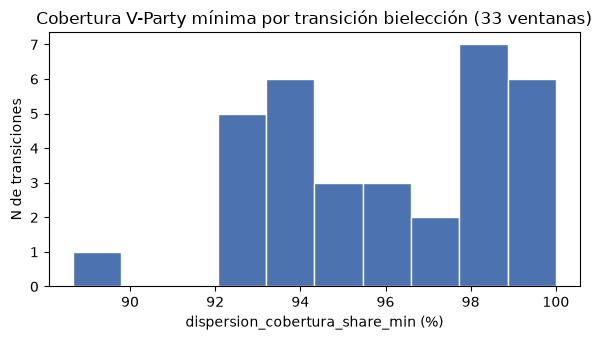

In [4]:
cobertura = pd.concat([df[["id_transicion", "nivel", "dispersion_cobertura_share_min"]] for df in paneles_h2.values()])
print(cobertura["dispersion_cobertura_share_min"].describe())

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(cobertura["dispersion_cobertura_share_min"], bins=10, color="#4C72B0", edgecolor="white")
ax.set_xlabel("dispersion_cobertura_share_min (%)")
ax.set_ylabel("N de transiciones")
ax.set_title("Cobertura V-Party mínima por transición bielección (33 ventanas)")
plt.tight_layout()
plt.show()

### Paso 4 — LASSO LOOCV: `magnitud_desplazamiento_ideologico`

Mismo algoritmo (coordinate descent manual) que
`ventana_t-1/03_desplazamiento_ideologico.ipynb`.

In [5]:
def estandarizar(X: pd.DataFrame) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    medias = X.mean(axis=0).values
    desvios = X.std(axis=0, ddof=0).values
    desvios_seguros = np.where(desvios == 0, 1.0, desvios)
    X_std = (X.values - medias) / desvios_seguros
    return X_std, medias, desvios_seguros


def soft_threshold(z: float, umbral: float) -> float:
    if z > umbral:
        return z - umbral
    elif z < -umbral:
        return z + umbral
    return 0.0


def lasso_coordinate_descent(X: np.ndarray, y: np.ndarray, alpha: float, tol: float = 1e-6, max_iter: int = 1000) -> np.ndarray:
    n, p = X.shape
    beta = np.zeros(p)
    for _ in range(max_iter):
        beta_anterior = beta.copy()
        for j in range(p):
            residuo_parcial = y - X @ beta + X[:, j] * beta[j]
            rho_j = X[:, j] @ residuo_parcial / n
            beta[j] = soft_threshold(rho_j, alpha)
        if np.max(np.abs(beta - beta_anterior)) < tol:
            break
    return beta


def alpha_max_lasso(X: np.ndarray, y: np.ndarray) -> float:
    n = len(y)
    return np.max(np.abs(X.T @ y)) / n


def lasso_loocv_manual(X_df: pd.DataFrame, y_ser: pd.Series, n_alphas: int = 50, factor_extension: float = 1.0) -> dict:
    n = len(y_ser)
    X_std_full, _, _ = estandarizar(X_df)
    y_full = y_ser.values
    alpha_max = alpha_max_lasso(X_std_full, y_full - y_full.mean()) * factor_extension
    alphas = np.logspace(np.log10(alpha_max * 1e-3), np.log10(alpha_max), n_alphas)
    errores = np.zeros((n, n_alphas))
    for i in range(n):
        idx_train = [k for k in range(n) if k != i]
        X_train_df, y_train = X_df.iloc[idx_train], y_ser.iloc[idx_train].values
        X_test_df, y_test = X_df.iloc[[i]], y_ser.iloc[i]
        X_train_std, medias_tr, desvios_tr = estandarizar(X_train_df)
        y_train_media = y_train.mean()
        y_train_centrado = y_train - y_train_media
        X_test_std = (X_test_df.values - medias_tr) / desvios_tr
        beta = np.zeros(X_train_std.shape[1])
        for j, alpha in enumerate(alphas[::-1]):
            beta = lasso_coordinate_descent(X_train_std, y_train_centrado, alpha, tol=1e-6, max_iter=1000)
            pred = y_train_media + X_test_std @ beta
            errores[i, len(alphas) - 1 - j] = (pred[0] - y_test) ** 2
    mean_mse = errores.mean(axis=0)
    se_mse = errores.std(axis=0, ddof=1) / np.sqrt(n)
    idx_min = mean_mse.argmin()
    umbral = mean_mse[idx_min] + se_mse[idx_min]
    alpha_1se = alphas[mean_mse <= umbral].max()
    return {"alphas": alphas, "mean_mse": mean_mse, "se_mse": se_mse, "alpha_min": alphas[idx_min], "alpha_1se": alpha_1se}


def baseline_trivial_loocv(y_ser: pd.Series) -> float:
    n = len(y_ser)
    errores = [(np.delete(y_ser.values, i).mean() - y_ser.values[i]) ** 2 for i in range(n)]
    return np.mean(errores)


def mse_en_alpha(X_df: pd.DataFrame, y_ser: pd.Series, alpha: float) -> float:
    n = len(y_ser)
    errores = []
    for i in range(n):
        idx_train = [k for k in range(n) if k != i]
        X_train_df, y_train = X_df.iloc[idx_train], y_ser.iloc[idx_train].values
        X_test_df, y_test = X_df.iloc[[i]], y_ser.iloc[i]
        X_train_std, medias, desvios = estandarizar(X_train_df)
        y_train_media = y_train.mean()
        X_test_std = (X_test_df.values - medias) / desvios
        beta = lasso_coordinate_descent(X_train_std, y_train - y_train_media, alpha)
        pred = y_train_media + X_test_std @ beta
        errores.append((pred[0] - y_test) ** 2)
    return np.mean(errores)


def ajustar_final(X_df: pd.DataFrame, y_ser: pd.Series, alpha: float) -> pd.Series:
    X_std, medias, desvios = estandarizar(X_df)
    y_centrado = y_ser.values - y_ser.values.mean()
    beta = lasso_coordinate_descent(X_std, y_centrado, alpha)
    return pd.Series(beta, index=X_df.columns)

In [6]:
TARGET = "magnitud_desplazamiento_ideologico"

def construir_Xy(nivel: str) -> tuple[pd.DataFrame, pd.Series]:
    df = paneles_h2[nivel]
    X = df[COLS_H2].copy()
    y = df[TARGET].copy()
    completas = X.notna().all(axis=1) & y.notna()
    n_incompletas = (~completas).sum()
    if n_incompletas:
        print(f"[{nivel}] excluye {n_incompletas} fila(s) por NaN: {df.loc[~completas, 'id_transicion'].tolist()}")
    X_final = X.loc[completas].reset_index(drop=True)
    y_final = y.loc[completas].reset_index(drop=True)

    constantes = X_final.columns[X_final.std(axis=0, ddof=0) == 0]
    if len(constantes):
        print(f"[{nivel}] excluye columna(s) sin varianza: {list(constantes)}")
        X_final = X_final.drop(columns=constantes)

    X_final = X_final.astype(float)
    return X_final, y_final


datos_final = {}
for nivel in NIVELES:
    X, y = construir_Xy(nivel)
    datos_final[nivel] = (X, y)
    print(f"{nivel}: N={len(y)}, P={X.shape[1]}")

[municipal] excluye columna(s) sin varianza: ['icc_cobertura_parcial', 'icg_cobertura_parcial', 'tc_oficial_cobertura_parcial']
municipal: N=11, P=54
[provincial] excluye columna(s) sin varianza: ['icc_cobertura_parcial', 'icg_cobertura_parcial', 'tc_oficial_cobertura_parcial']
provincial: N=11, P=54
[nacional] excluye columna(s) sin varianza: ['icc_cobertura_parcial', 'icg_cobertura_parcial', 'tc_oficial_cobertura_parcial']
nacional: N=11, P=54


In [7]:
resultados_cv = {}
for nivel in NIVELES:
    X_df, y_ser = datos_final[nivel]
    resultados_cv[nivel] = lasso_loocv_manual(X_df, y_ser, factor_extension=3.0)
    r = resultados_cv[nivel]
    print(f"{nivel}: alpha_min={r['alpha_min']:.4f}  alpha_1se={r['alpha_1se']:.4f}  (techo grilla={r['alphas'][-1]:.4f})")

municipal: alpha_min=0.0315  alpha_1se=0.1484  (techo grilla=0.8054)
provincial: alpha_min=0.0680  alpha_1se=0.1825  (techo grilla=0.9907)
nacional: alpha_min=0.0630  alpha_1se=0.1947  (techo grilla=0.6923)


In [8]:
resumen = []
coeficientes_min = {}
for nivel in NIVELES:
    X_df, y_ser = datos_final[nivel]
    r = resultados_cv[nivel]
    base = baseline_trivial_loocv(y_ser)
    mse_min = mse_en_alpha(X_df, y_ser, r["alpha_min"])
    mse_1se = mse_en_alpha(X_df, y_ser, r["alpha_1se"])
    resumen.append({
        "nivel": nivel,
        "baseline_mse": base,
        "mejora_alpha_min_%": 100 * (1 - mse_min / base),
        "mejora_alpha_1se_%": 100 * (1 - mse_1se / base),
    })
    coeficientes_min[nivel] = ajustar_final(X_df, y_ser, r["alpha_min"])

tabla_resumen = pd.DataFrame(resumen).set_index("nivel")
print(tabla_resumen)

            baseline_mse  mejora_alpha_min_%  mejora_alpha_1se_%
nivel                                                           
municipal       0.129561           44.937226           21.505295
provincial      0.183523           52.063005           31.397705
nacional        0.094137           38.637941           12.400307


In [9]:
tabla_coef_min = pd.DataFrame(coeficientes_min)
tabla_coef_min = tabla_coef_min[(tabla_coef_min != 0).any(axis=1)]
print("Coeficientes distintos de cero (alpha_min):")
tabla_coef_min

Coeficientes distintos de cero (alpha_min):


,municipal,provincial,nacional
hacinamiento_medio_cobertura_parcial,0.000000,0.030101,0.039898
hacinamiento_medio_volatilidad_trim,0.000000,0.042390,0.025024
icc_final_trim,0.185544,0.171360,0.133774
icg_volatilidad_trim,-0.007066,0.000000,0.000000
ipc_cobertura_parcial,0.065727,0.000000,0.000000
pct_hogares_ayuda_social_gobierno_pendiente_trim,0.033039,0.000000,0.000000
pct_hogares_vendio_pertenencias_final_trim,-0.001483,0.000000,0.000000
pct_sin_cobertura_salud_pendiente_trim,0.027432,0.000000,0.000000
reservas_nivel_trim,0.000000,-0.016154,-0.018744
resultado_fiscal_pendiente_trim,-0.085398,-0.096442,0.000000


### Paso 5 — `cuadrante_desplazamiento` como variable descriptiva

No se arma un clasificador nuevo (LASSO es para variable continua) --
tabla cruzada simple contra el signo del predictor más fuerte de H1/H4 en
`ventana_t-1/` (`icg_pendiente_vc`), acá con su equivalente `icg_pendiente_trim`,
para ver si la dirección del desplazamiento se asocia a la dirección de la
confianza en el gobierno a lo largo del bloque largo.

In [10]:
for nivel in NIVELES:
    df = paneles_h2[nivel]
    tabla = df.dropna(subset=["cuadrante_desplazamiento", "icg_pendiente_trim"]).copy()
    tabla["icg_pendiente_trim_signo"] = np.where(tabla["icg_pendiente_trim"] > 0, "icg_sube", "icg_baja")
    print(f"--- {nivel} ---")
    print(pd.crosstab(tabla["cuadrante_desplazamiento"], tabla["icg_pendiente_trim_signo"]))
    print()

--- municipal ---
icg_pendiente_trim_signo  icg_baja  icg_sube
cuadrante_desplazamiento                    
derecha_conservador              5         2
izquierda_progresista            1         3

--- provincial ---
icg_pendiente_trim_signo  icg_baja  icg_sube
cuadrante_desplazamiento                    
derecha_conservador              5         2
izquierda_progresista            1         3

--- nacional ---
icg_pendiente_trim_signo  icg_baja  icg_sube
cuadrante_desplazamiento                    
derecha_conservador              5         2
izquierda_progresista            1         3

